In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Load your data into a DataFrame
data = pd.read_csv('/home/mostah/workspace/fairness/scores/GD_results/decisionDirection.csv')

# # Bar chart for average scores
# plt.figure(figsize=(12, 6))
# sns.barplot(x='Folder Name', y='rouge1', data=data)
# plt.title('Average ROUGE-1 Scores by Group')
# plt.xticks(rotation=90)
# plt.ylabel('ROUGE-1 Score')
# plt.xlabel('Group')
# plt.tight_layout()
# plt.show()

# Heatmap for all scores
plt.figure(figsize=(18, 8))
sns.heatmap(data.set_index('Folder Name').T, annot=True, cmap='coolwarm')
plt.title('Heatmap of Scores by Group')
plt.ylabel('Metrics')
plt.xlabel('Group')
plt.tight_layout()
plt.show()


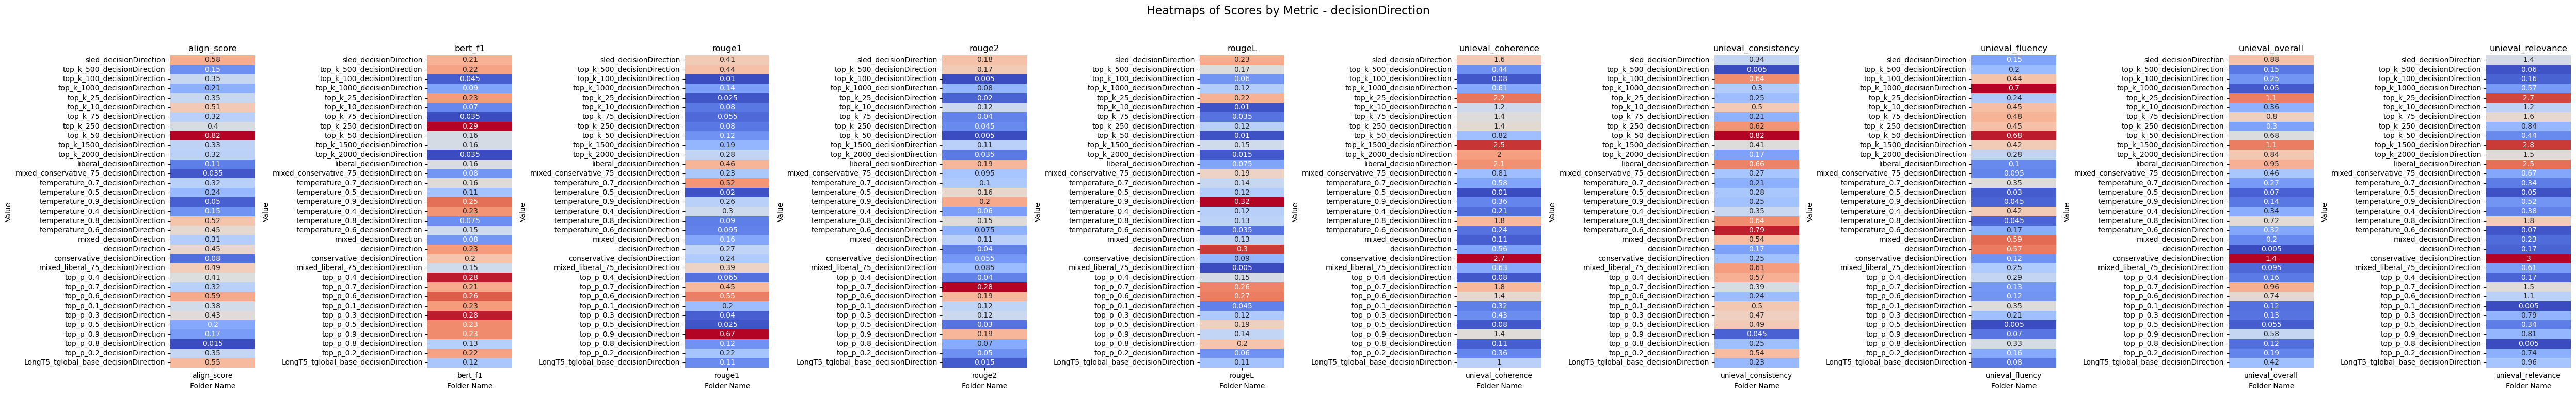

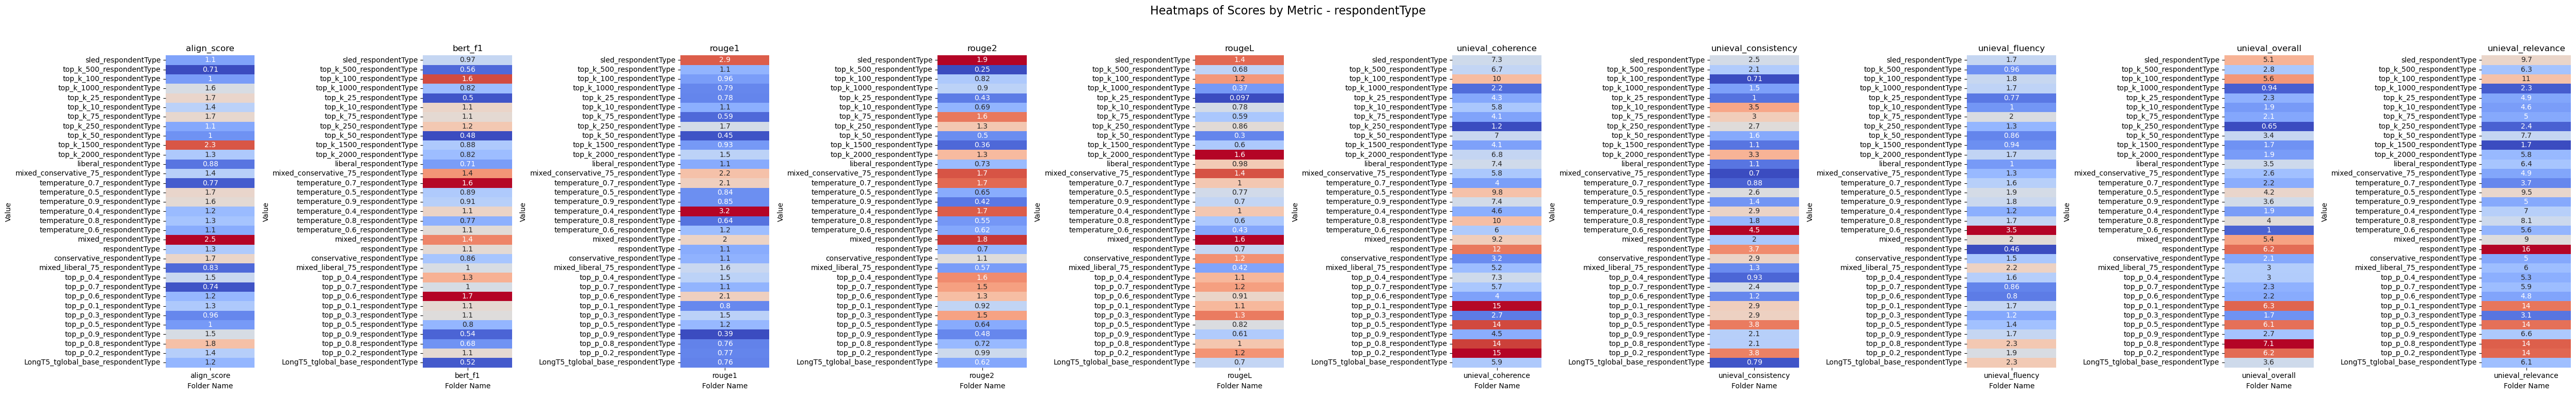

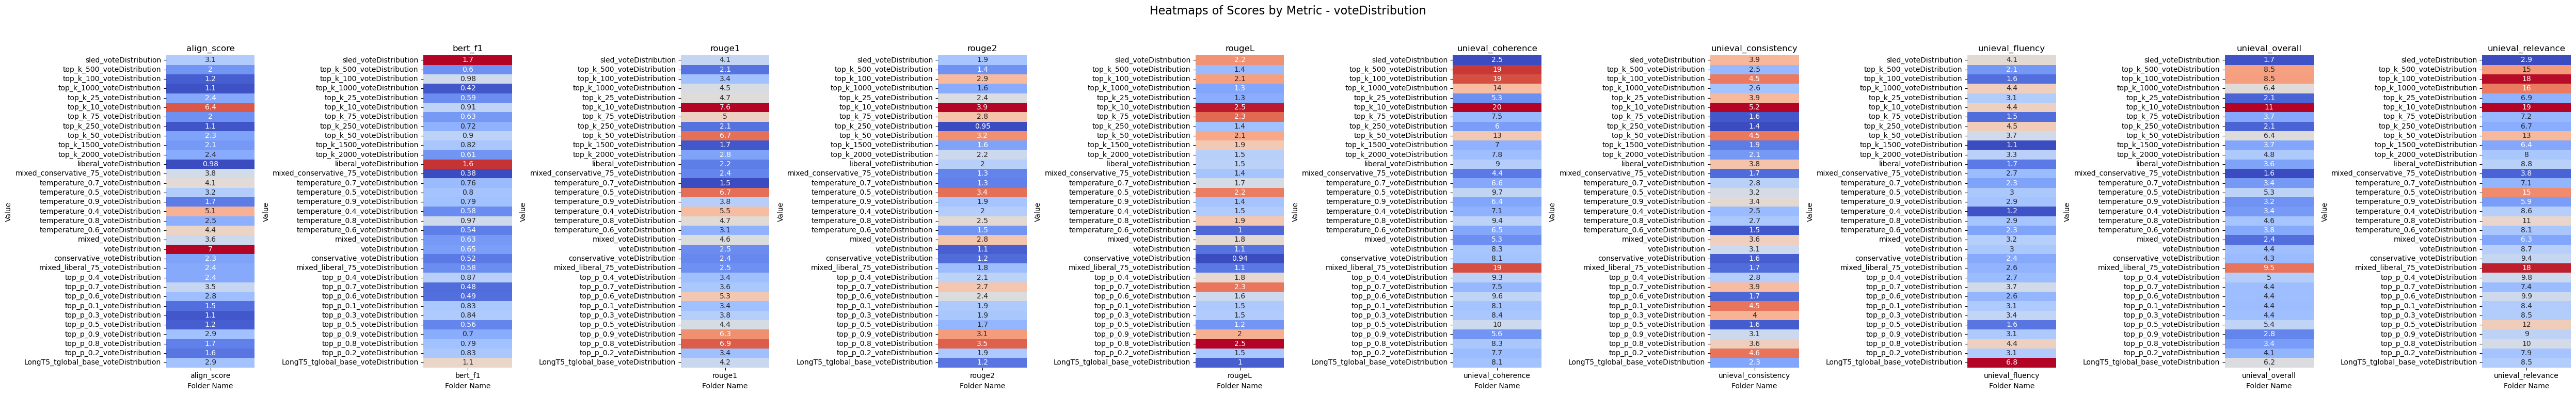

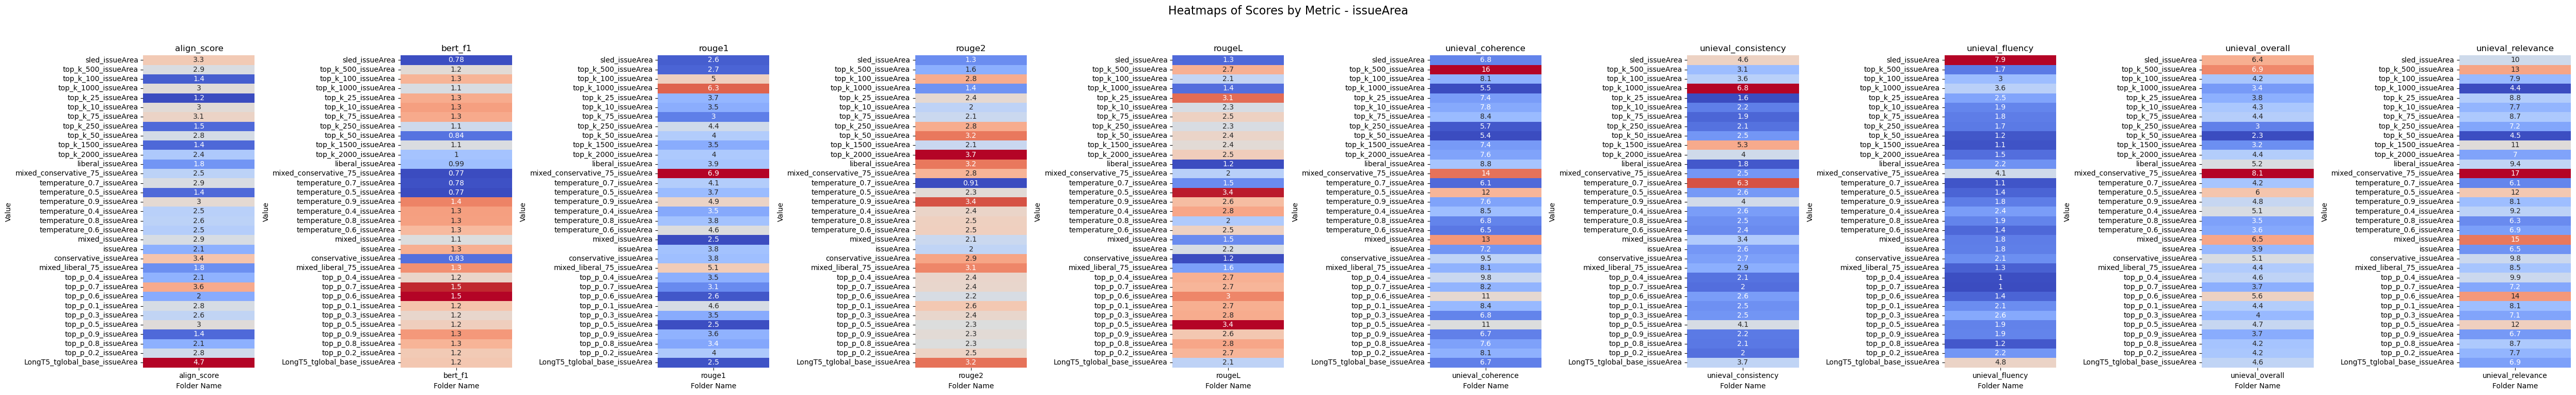

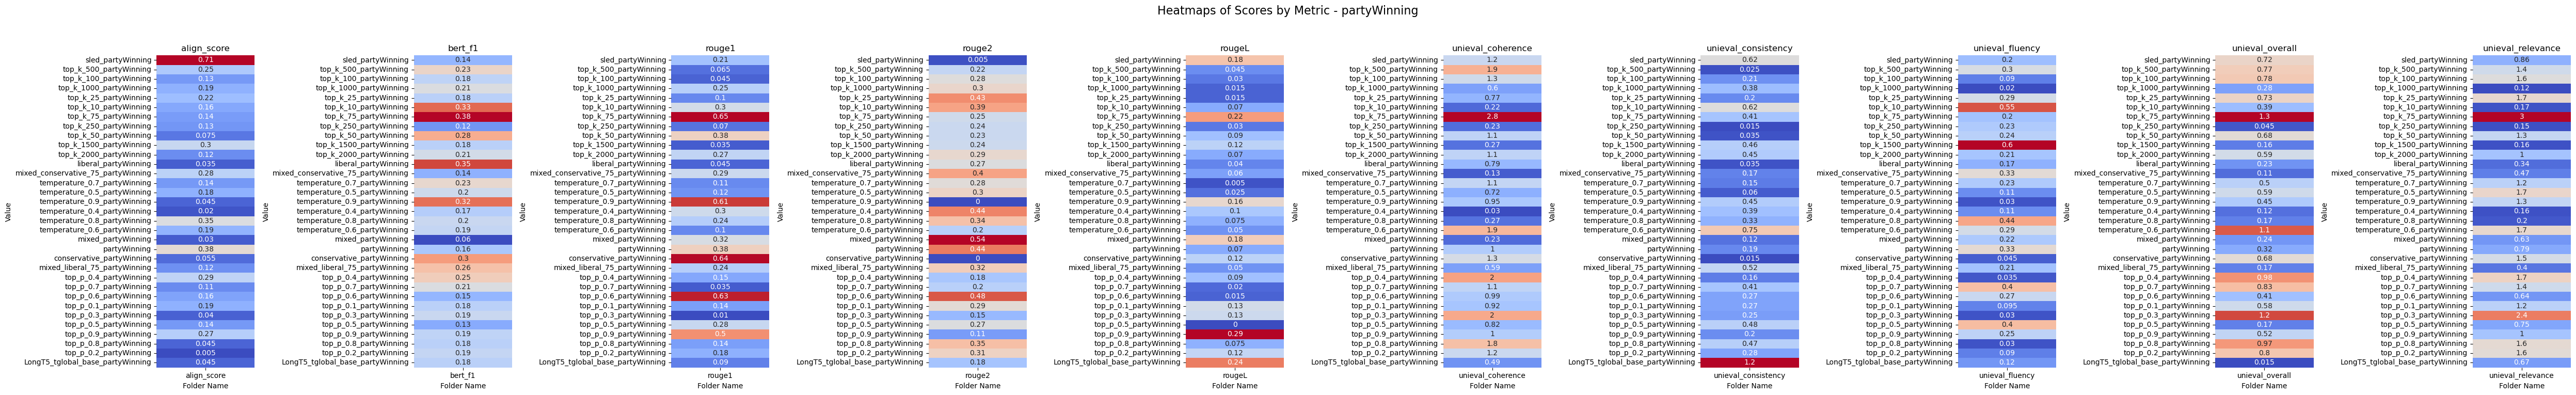

In [39]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import glob
import os

# Specify the path to the directory containing the CSV files
path = '/home/mostah/workspace/fairness/scores/GD_results/groups'

# Use glob to get all CSV files in the directory
csv_files = glob.glob(os.path.join(path, '*.csv'))

# Iterate over each CSV file
for csv_file in csv_files:
    # Load the data into a DataFrame
    data = pd.read_csv(csv_file)
    
    # Extract the file name without the directory and extension for the plot title
    file_name = os.path.basename(csv_file).replace('.csv', '')
    
    # Set 'Folder Name' as the index
    data.set_index('Folder Name', inplace=True)
    
    # Sort the columns (metric names)
    data = data.sort_index(axis=1)
    
    # Create a grid of subplots, one for each metric
    metrics = data.columns  # All columns except 'Folder Name' are metrics
    num_metrics = len(metrics)
    fig, axes = plt.subplots(nrows=1, ncols=num_metrics, figsize=(5 * num_metrics, 8))
    
    # Plot each metric in a separate subplot
    for ax, metric in zip(axes, metrics):
        # Plot the heatmap for each metric
        sns.heatmap(data[[metric]], annot=True, cmap='coolwarm', ax=ax, cbar=False)
        ax.set_title(metric)
        ax.set_xlabel('Folder Name')
        ax.set_ylabel('Value')
    
    # Set the main title for the entire figure
    plt.suptitle(f'Heatmaps of Scores by Metric - {file_name}', fontsize=16)
    plt.tight_layout(rect=[0, 0.03, 1, 0.95])  # Adjust layout to make room for the main title
    
    # Show the plot
    plt.show()


# RQ3 temperature

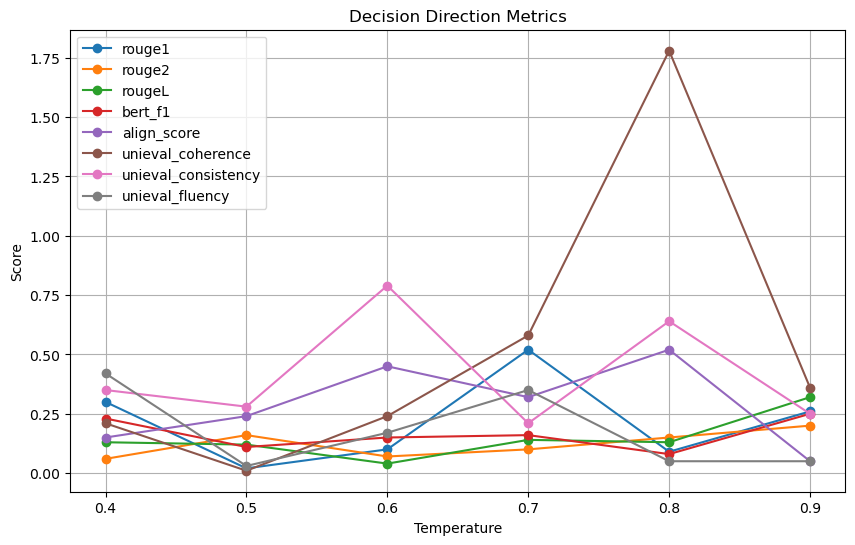

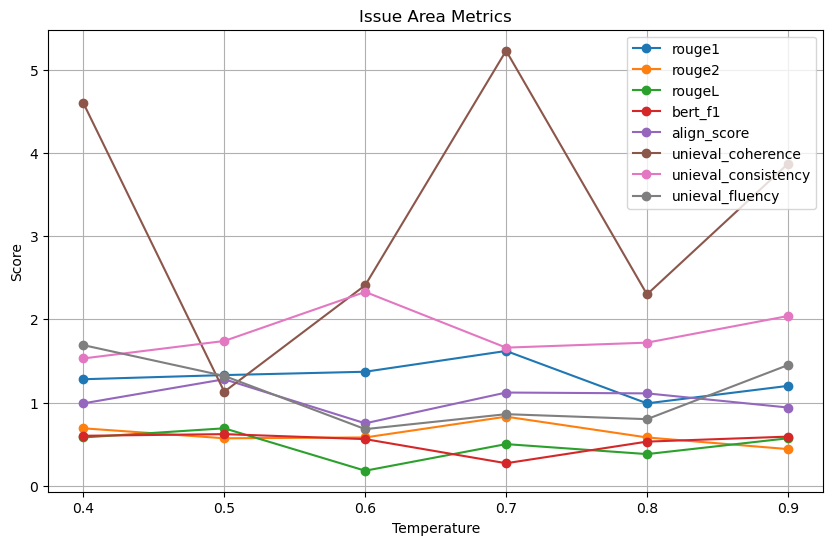

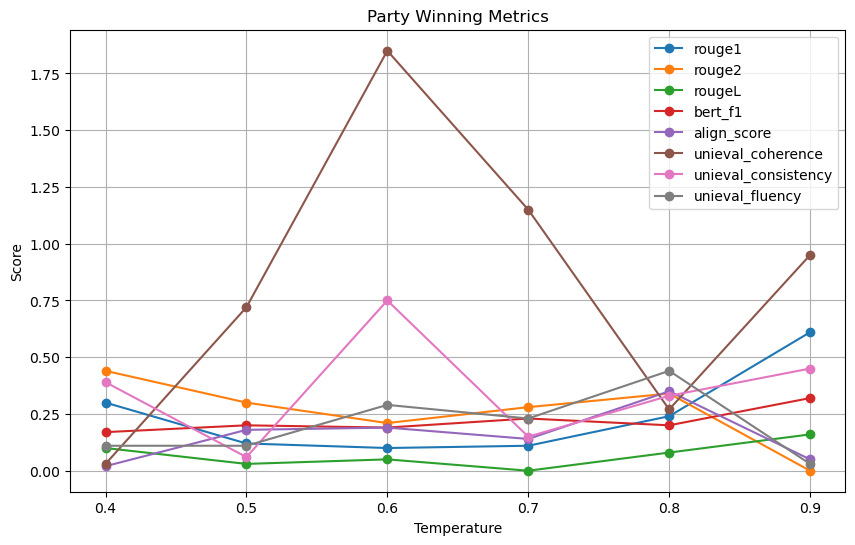

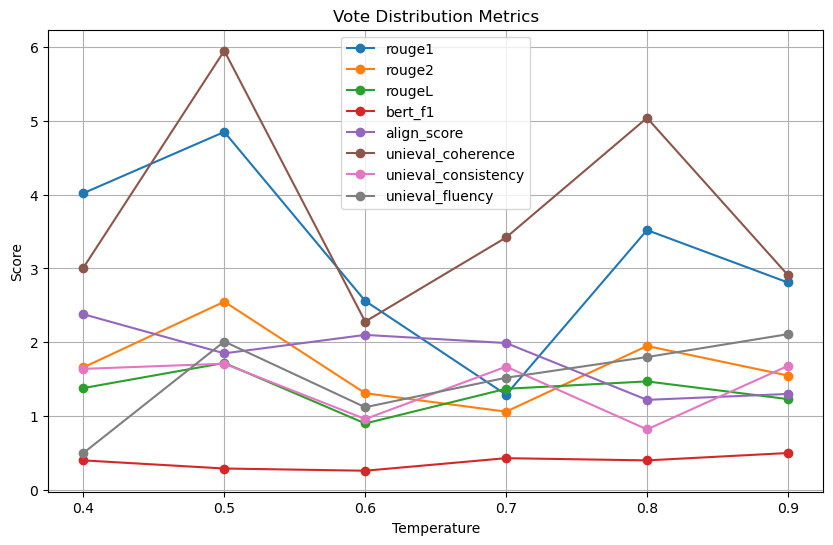

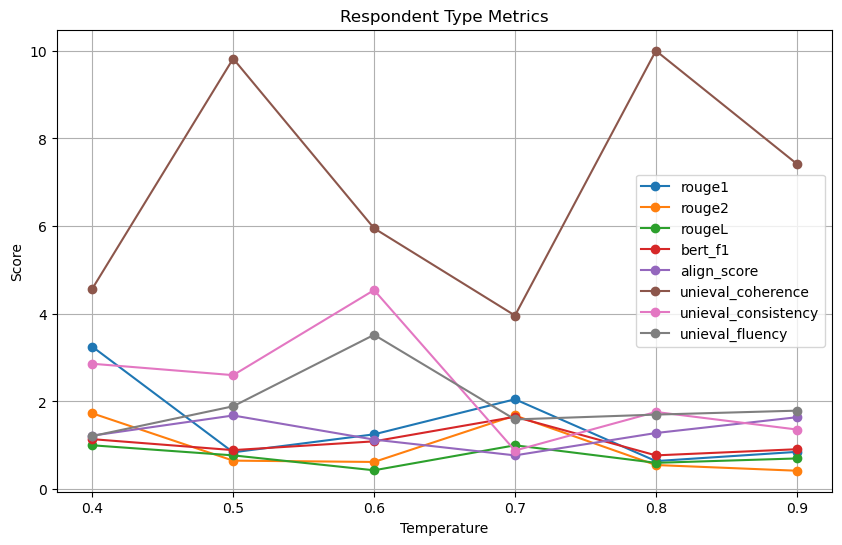

In [2]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

import pandas as pd

# Data for each section
decision_direction_data = {
    'temp': [0.4, 0.5, 0.6, 0.7, 0.8, 0.9],
    'rouge1': [0.30, 0.02, 0.10, 0.52, 0.09, 0.26],
    'rouge2': [0.06, 0.16, 0.07, 0.10, 0.15, 0.20],
    'rougeL': [0.13, 0.12, 0.04, 0.14, 0.13, 0.32],
    'bert_f1': [0.23, 0.11, 0.15, 0.16, 0.08, 0.25],
    'align_score': [0.15, 0.24, 0.45, 0.32, 0.52, 0.05],
    'unieval_coherence': [0.21, 0.01, 0.24, 0.58, 1.78, 0.36],
    'unieval_consistency': [0.35, 0.28, 0.79, 0.21, 0.64, 0.25],
    'unieval_fluency': [0.42, 0.03, 0.17, 0.35, 0.05, 0.05]
}

issue_area_data = {
    'temp': [0.4, 0.5, 0.6, 0.7, 0.8, 0.9],
    'rouge1': [1.28, 1.33, 1.37, 1.62, 0.99, 1.20],
    'rouge2': [0.69, 0.57, 0.58, 0.83, 0.58, 0.44],
    'rougeL': [0.58, 0.69, 0.18, 0.50, 0.38, 0.57],
    'bert_f1': [0.60, 0.62, 0.56, 0.27, 0.53, 0.59],
    'align_score': [0.99, 1.28, 0.75, 1.12, 1.11, 0.94],
    'unieval_coherence': [4.60, 1.13, 2.41, 5.23, 2.30, 3.87],
    'unieval_consistency': [1.53, 1.74, 2.33, 1.66, 1.72, 2.04],
    'unieval_fluency': [1.69, 1.32, 0.68, 0.86, 0.80, 1.45]
}

party_winning_data = {
    'temp': [0.4, 0.5, 0.6, 0.7, 0.8, 0.9],
    'rouge1': [0.30, 0.12, 0.10, 0.11, 0.24, 0.61],
    'rouge2': [0.44, 0.30, 0.21, 0.28, 0.34, 0.00],
    'rougeL': [0.10, 0.03, 0.05, 0.00, 0.08, 0.16],
    'bert_f1': [0.17, 0.20, 0.19, 0.23, 0.20, 0.32],
    'align_score': [0.02, 0.18, 0.19, 0.14, 0.35, 0.05],
    'unieval_coherence': [0.03, 0.72, 1.85, 1.15, 0.27, 0.95],
    'unieval_consistency': [0.39, 0.06, 0.75, 0.15, 0.33, 0.45],
    'unieval_fluency': [0.11, 0.11, 0.29, 0.23, 0.44, 0.03]
}

vote_distribution_data = {
    'temp': [0.4, 0.5, 0.6, 0.7, 0.8, 0.9],
    'rouge1': [4.02, 4.85, 2.56, 1.29, 3.52, 2.81],
    'rouge2': [1.66, 2.55, 1.31, 1.06, 1.95, 1.55],
    'rougeL': [1.38, 1.72, 0.90, 1.37, 1.47, 1.23],
    'bert_f1': [0.40, 0.29, 0.26, 0.43, 0.40, 0.50],
    'align_score': [2.38, 1.85, 2.10, 1.99, 1.22, 1.30],
    'unieval_coherence': [3.01, 5.95, 2.28, 3.42, 5.04, 2.91],
    'unieval_consistency': [1.64, 1.71, 0.96, 1.67, 0.82, 1.68],
    'unieval_fluency': [0.50, 2.01, 1.12, 1.52, 1.80, 2.11]
}

respondent_type_data = {
    'temp': [0.4, 0.5, 0.6, 0.7, 0.8, 0.9],
    'rouge1': [3.25, 0.84, 1.25, 2.05, 0.64, 0.85],
    'rouge2': [1.73, 0.65, 0.62, 1.68, 0.55, 0.42],
    'rougeL': [1.00, 0.77, 0.43, 1.00, 0.60, 0.70],
    'bert_f1': [1.14, 0.89, 1.09, 1.65, 0.77, 0.91],
    'align_score': [1.22, 1.68, 1.13, 0.77, 1.28, 1.64],
    'unieval_coherence': [4.57, 9.82, 5.95, 3.96, 10.00, 7.42],
    'unieval_consistency': [2.86, 2.60, 4.54, 0.88, 1.76, 1.36],
    'unieval_fluency': [1.21, 1.89, 3.52, 1.59, 1.70, 1.79]
}

# Create DataFrames
decision_direction_df = pd.DataFrame(decision_direction_data)
issue_area_df = pd.DataFrame(issue_area_data)
party_winning_df = pd.DataFrame(party_winning_data)
vote_distribution_df = pd.DataFrame(vote_distribution_data)
respondent_type_df = pd.DataFrame(respondent_type_data)



import matplotlib.pyplot as plt

def plot_metrics(df, title):
    plt.figure(figsize=(10, 6))
    for column in df.columns[1:]:
        plt.plot(df['temp'], df[column], marker='o', label=column)
    plt.title(title)
    plt.xlabel('Temperature')
    plt.ylabel('Score')
    plt.legend()
    plt.grid(True)
    plt.show()

# Plot each section
plot_metrics(decision_direction_df, 'Decision Direction Metrics')
plot_metrics(issue_area_df, 'Issue Area Metrics')
plot_metrics(party_winning_df, 'Party Winning Metrics')
plot_metrics(vote_distribution_df, 'Vote Distribution Metrics')
plot_metrics(respondent_type_df, 'Respondent Type Metrics')



# RQ3 top-p

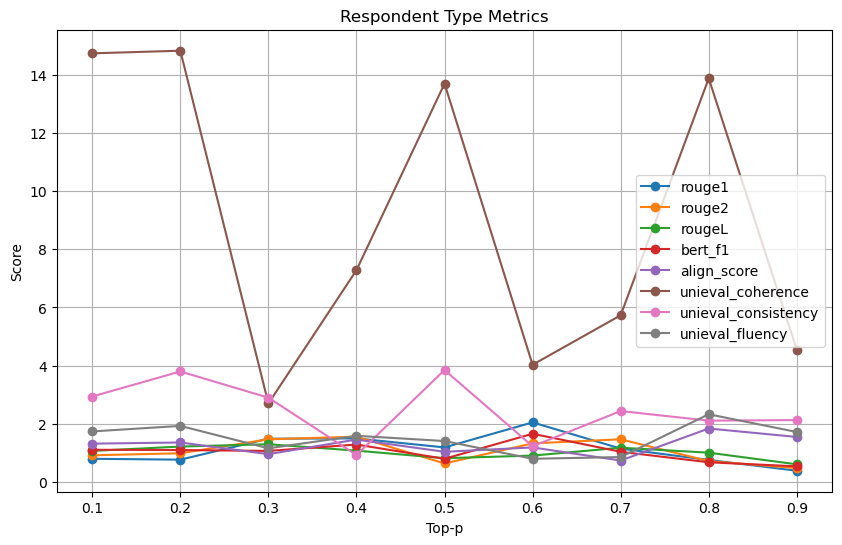

In [1]:
import pandas as pd
import matplotlib.pyplot as plt

# Data for each section
decision_direction_data = {
    'top-p': [0.1, 0.2, 0.3, 0.4, 0.5, 0.6, 0.7, 0.8, 0.9],
    'rouge1': [0.20, 0.22, 0.04, 0.07, 0.03, 0.55, 0.45, 0.12, 0.67],
    'rouge2': [0.12, 0.05, 0.13, 0.04, 0.03, 0.19, 0.28, 0.07, 0.19],
    'rougeL': [0.04, 0.06, 0.12, 0.15, 0.19, 0.27, 0.26, 0.21, 0.14],
    'bert_f1': [0.23, 0.22, 0.28, 0.28, 0.23, 0.26, 0.21, 0.13, 0.23],
    'align_score': [0.38, 0.35, 0.43, 0.41, 0.20, 0.59, 0.32, 0.01, 0.17],
    'unieval_coherence': [0.32, 0.36, 0.43, 0.08, 1.45, 1.79, 0.11, 1.38],
    'unieval_consistency': [0.50, 0.54, 0.47, 0.57, 0.49, 0.24, 0.39, 0.25, 0.04],
    'unieval_fluency': [0.35, 0.16, 0.21, 0.29, 0.00, 0.13, 0.13, 0.33, 0.07]
}

issue_area_data = {
    'top-p': [0.1, 0.2, 0.3, 0.4, 0.5, 0.6, 0.7, 0.8, 0.9],
    'rouge1': [1.55, 1.79, 1.09, 2.13, 0.62, 1.59, 0.96, 2.04, 1.27],
    'rouge2': [1.00, 0.98, 0.77, 0.89, 0.71, 0.75, 0.19, 0.78, 0.78],
    'rougeL': [0.69, 0.73, 0.83, 0.43, 0.61, 0.51, 0.59, 0.57, 0.49],
    'bert_f1': [0.66, 0.65, 0.59, 0.59, 0.50, 0.52, 0.69, 0.63, 0.63],
    'align_score': [1.10, 0.94, 1.12, 1.18, 1.31, 0.91, 1.12, 1.40, 1.14],
    'unieval_coherence': [3.47, 2.81, 2.07, 8.45, 1.65, 3.79, 5.55, 4.43, 4.17],
    'unieval_consistency': [1.88, 1.22, 2.12, 1.91, 2.36, 2.12, 1.47, 1.76, 1.98],
    'unieval_fluency': [0.76, 1.26, 0.74, 0.57, 1.27, 1.08, 0.99, 1.29, 0.83]
}

party_winning_data = {
    'top-p': [0.1, 0.2, 0.3, 0.4, 0.5, 0.6, 0.7, 0.8, 0.9],
    'rouge1': [0.14, 0.18, 0.01, 0.15, 0.28, 0.63, 0.04, 0.14, 0.50],
    'rouge2': [0.29, 0.31, 0.15, 0.18, 0.27, 0.48, 0.21, 0.35, 0.11],
    'rougeL': [0.13, 0.12, 0.13, 0.09, 0.00, 0.02, 0.02, 0.07, 0.29],
    'bert_f1': [0.18, 0.19, 0.19, 0.25, 0.13, 0.15, 0.21, 0.18, 0.19],
    'align_score': [0.19, 0.01, 0.04, 0.29, 0.14, 0.16, 0.11, 0.05, 0.27],
    'unieval_coherence': [0.92, 1.21, 1.97, 2.02, 0.82, 0.99, 1.13, 1.78, 1.02],
    'unieval_consistency': [0.27, 0.28, 0.25, 0.16, 0.48, 0.27, 0.41, 0.47, 0.20],
    'unieval_fluency': [0.09, 0.09, 0.03, 0.03, 0.40, 0.27, 0.40, 0.03, 0.25]
}

vote_distribution_data = {
    'top-p': [0.1, 0.2, 0.3, 0.4, 0.5, 0.6, 0.7, 0.8, 0.9],
    'rouge1': [2.59, 2.51, 2.55, 2.49, 3.12, 3.82, 2.77, 5.00, 4.61],
    'rouge2': [1.54, 1.49, 1.50, 1.61, 1.41, 1.84, 2.08, 2.44, 2.33],
    'rougeL': [1.19, 1.16, 1.25, 1.34, 1.07, 1.24, 1.60, 1.78, 1.64],
    'bert_f1': [0.48, 0.47, 0.44, 0.42, 0.34, 0.43, 0.33, 0.53, 0.42],
    'align_score': [1.01, 1.13, 0.98, 1.42, 0.74, 1.33, 1.85, 1.43, 1.56],
    'unieval_coherence': [4.85, 5.49, 4.52, 4.69, 5.89, 5.27, 4.42, 5.20, 2.42],
    'unieval_consistency': [2.62, 2.63, 2.45, 1.36, 0.33, 0.49, 2.09, 2.15, 1.47],
    'unieval_fluency': [2.03, 1.98, 2.14, 1.48, 0.71, 1.54, 2.52, 2.81, 2.29]
}


respondent_type_data = {
    'top-p': [0.1, 0.2, 0.3, 0.4, 0.5, 0.6, 0.7, 0.8, 0.9],
    'rouge1': [0.80, 0.77, 1.49, 1.50, 1.19, 2.05, 1.15, 0.76, 0.39],
    'rouge2': [0.92, 0.99, 1.47, 1.56, 0.64, 1.33, 1.47, 0.72, 0.48],
    'rougeL': [1.07, 1.22, 1.30, 1.08, 0.82, 0.91, 1.18, 1.01, 0.61],
    'bert_f1': [1.11, 1.10, 1.07, 1.29, 0.80, 1.66, 1.04, 0.68, 0.54],
    'align_score': [1.32, 1.36, 0.96, 1.46, 1.04, 1.19, 0.74, 1.84, 1.55],
    'unieval_coherence': [14.73, 14.82, 2.70, 7.28, 13.69, 4.03, 5.73, 13.87, 4.55],
    'unieval_consistency': [2.94, 3.80, 2.90, 0.93, 3.85, 1.23, 2.44, 2.11, 2.13],
    'unieval_fluency': [1.74, 1.93, 1.16, 1.59, 1.41, 0.80, 0.86, 2.33, 1.72]
}

respondent_type_df = pd.DataFrame(respondent_type_data)

def plot_metrics(df, title):
    plt.figure(figsize=(10, 6))
    for column in df.columns[1:]:
        plt.plot(df['top-p'], df[column], marker='o', label=column)
    plt.title(title)
    plt.xlabel('Top-p')
    plt.ylabel('Score')
    plt.legend()
    plt.grid(True)
    plt.show()

# Plot the Respondent Type metrics
plot_metrics(respondent_type_df, 'Respondent Type Metrics')


# RQ3 top-k

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
decision_direction_data = {
    'top-k': [10, 25, 50, 75, 100, 250, 500, 1000, 1500, 2000],
    # 'rouge1': [0.08, 0.03, 0.12, 0.05, 0.01, 0.08, 0.44, 0.14, 0.19, 0.28],
    # 'rouge2': [0.13, 0.02, 0.01, 0.04, 0.00, 0.04, 0.17, 0.08, 0.11, 0.03],
    'rougeL': [0.01, 0.22, 0.01, 0.04, 0.06, 0.13, 0.17, 0.12, 0.15, 0.02],
    'bert_f1': [0.07, 0.23, 0.16, 0.03, 0.04, 0.29, 0.22, 0.09, 0.16, 0.03],
    'align_score': [0.51, 0.35, 0.82, 0.32, 0.35, 0.40, 0.15, 0.21, 0.33, 0.32],
    'unieval_coherence': [1.20, 2.23, 0.82, 1.36, 0.08, 1.41, 0.44, 0.61, 2.54, 1.97],
    # 'unieval_consistency': [0.50, 0.25, 0.82, 0.21, 0.64, 0.63, 0.00, 0.30, 0.41, 0.17],
    'unieval_fluency': [0.45, 0.24, 0.68, 0.48, 0.44, 0.45, 0.20, 0.70, 0.42, 0.28]
}
issue_area_data = {
    'top-k': [10, 25, 50, 75, 100, 250, 500, 1000, 1500, 2000],
    # 'rouge1': [2.20, 1.63, 1.01, 2.12, 1.28, 0.77, 1.07, 1.33, 0.97, 2.03],
    # 'rouge2': [1.13, 1.29, 0.30, 0.98, 0.48, 0.28, 0.40, 0.30, 0.45, 1.14],
    'rougeL': [0.75, 0.81, 0.35, 0.79, 0.59, 0.59, 0.56, 0.17, 0.52, 0.86],
    'bert_f1': [0.52, 0.58, 0.55, 0.52, 0.45, 0.52, 0.42, 0.34, 0.58, 0.35],
    'align_score': [0.72, 0.71, 0.96, 0.99, 0.93, 0.48, 0.85, 1.81, 0.96, 1.04],
    'unieval_coherence': [2.39, 3.50, 4.01, 6.19, 3.84, 5.00, 4.28, 2.58, 5.08, 6.39],
    # 'unieval_consistency': [2.13, 1.63, 1.41, 1.26, 2.44, 2.22, 1.21, 2.49, 1.95, 2.52],
    'unieval_fluency': [1.01, 0.87, 1.35, 2.06, 1.40, 1.20, 1.36, 0.78, 0.70, 1.25]
}
party_winning_data = {
    'top-k': [10, 25, 50, 75, 100, 250, 500, 1000, 1500, 2000],
    # 'rouge1': [0.30, 0.10, 0.38, 0.65, 0.04, 0.07, 0.07, 0.25, 0.04, 0.27],
    # 'rouge2': [0.39, 0.43, 0.23, 0.25, 0.28, 0.24, 0.22, 0.30, 0.24, 0.29],
    'rougeL': [0.07, 0.02, 0.09, 0.22, 0.03, 0.03, 0.04, 0.02, 0.12, 0.07],
    'bert_f1': [0.33, 0.18, 0.28, 0.38, 0.18, 0.12, 0.23, 0.21, 0.18, 0.21],
    'align_score': [0.16, 0.22, 0.08, 0.14, 0.13, 0.13, 0.25, 0.19, 0.30, 0.12],
    'unieval_coherence': [0.22, 0.77, 1.11, 2.77, 1.27, 0.23, 1.91, 0.60, 0.27, 1.11],
    # 'unieval_consistency': [0.63, 0.20, 0.04, 0.41, 0.21, 0.02, 0.03, 0.38, 0.46, 0.45],
    'unieval_fluency': [0.55, 0.29, 0.24, 0.20, 0.09, 0.23, 0.30, 0.02, 0.60, 0.21]
}
vote_distribution_data = {
    'top-k': [10, 25, 50, 75, 100, 250, 500, 1000, 1500, 2000],
    # 'rouge1': [5.66, 3.57, 4.87, 4.13, 2.62, 1.43, 1.74, 3.30, 1.42, 1.94],
    # 'rouge2': [3.00, 2.02, 2.48, 2.29, 2.21, 0.83, 1.26, 1.34, 1.28, 1.69],
    'rougeL': [1.98, 1.23, 1.69, 1.94, 1.85, 1.16, 1.19, 1.09, 1.54, 1.37],
    'bert_f1': [0.62, 0.35, 0.53, 0.38, 0.55, 0.39, 0.34, 0.32, 0.46, 0.42],
    'align_score': [2.90, 1.25, 1.34, 1.03, 1.06, 0.78, 1.44, 0.87, 1.46, 1.52],
    'unieval_coherence': [7.17, 2.44, 5.83, 4.01, 5.22, 3.25, 10.53, 9.54, 4.07, 4.29],
    # 'unieval_consistency': [2.76, 2.28, 2.44, 0.86, 1.88, 0.87, 0.91, 1.71, 1.00, 1.11],
    'unieval_fluency': [2.87, 2.62, 2.61, 1.34, 1.07, 2.31, 1.75, 2.79, 0.34, 1.45]
}
respondent_type_data = {
    'top-k': [10, 25, 50, 75, 100, 250, 500, 1000, 1500, 2000],
    # 'rouge1': [1.10, 0.78, 0.45, 0.59, 0.96, 1.71, 1.15, 0.79, 0.93, 1.50],
    # 'rouge2': [0.69, 0.43, 0.50, 1.63, 0.82, 1.28, 0.25, 0.90, 0.36, 1.35],
    'rougeL': [0.78, 0.10, 0.30, 0.59, 1.20, 0.86, 0.68, 0.37, 0.60, 1.57],
    'bert_f1': [1.13, 0.50, 0.48, 1.10, 1.55, 1.20, 0.56, 0.82, 0.88, 0.82],
    'align_score': [1.39, 1.68, 1.01, 1.66, 1.05, 1.11, 0.71, 1.56, 2.29, 1.32],
    'unieval_coherence': [5.76, 4.34, 7.04, 4.11, 10.10, 1.20, 6.74, 2.21, 4.05, 6.80],
    # 'unieval_consistency': [3.45, 1.04, 1.59, 2.97, 0.71, 2.65, 2.05, 1.49, 1.06, 3.32],
    'unieval_fluency': [1.00, 0.77, 0.86, 1.95, 1.76, 1.29, 0.96, 1.67, 0.94, 1.69]
}

# Create DataFrames
decision_direction_df = pd.DataFrame(decision_direction_data)
issue_area_df = pd.DataFrame(issue_area_data)
party_winning_df = pd.DataFrame(party_winning_data)
vote_distribution_df = pd.DataFrame(vote_distribution_data)
respondent_type_df = pd.DataFrame(respondent_type_data)

def plot_metrics(df, title):
    plt.figure(figsize=(10, 6))
    for column in df.columns[1:]:
        plt.plot(df['top-k'], df[column], marker='o', label=column)
    plt.title(title)
    plt.xlabel('Top-k')
    plt.ylabel('Score')
    plt.legend()
    plt.grid(True)
    plt.show()

# Plot each section
plot_metrics(decision_direction_df, 'Decision Direction Metrics')
plot_metrics(issue_area_df, 'Issue Area Metrics')
plot_metrics(party_winning_df, 'Party Winning Metrics')
plot_metrics(vote_distribution_df, 'Vote Distribution Metrics')
plot_metrics(respondent_type_df, 'Respondent Type Metrics')


# RQ1

In [59]:
import pandas as pd
decision_direction_data = {
    'Model-Name': ['SLED-BART', 'LED', 'Longt5'],
    # 'rouge1': [0.41, 0.27, 0.11],
    # 'rouge2': [0.18, 0.04, 0.02],
    'rougeL': [0.23, 0.30, 0.11],
    'bert_f1': [0.21, 0.23, 0.12],
    'align_score': [0.58, 0.45, 0.55],
    'unieval_coherence': [1.63, 0.56, 1.03],
    # 'unieval_consistency': [0.34, 0.17, 0.23],
    'unieval_fluency': [0.15, 0.57, 0.08]
}
issue_area_data = {
    'Model-Name': ['SLED-BART', 'LED', 'Longt5'],
    # 'rouge1': [1.34, 1.76, 0.83],
    # 'rouge2': [0.66, 0.39, 0.32],
    'rougeL': [0.57, 0.32, 0.34],
    'bert_f1': [0.57, 0.64, 0.73],
    'align_score': [1.14, 1.25, 1.15],
    'unieval_coherence': [4.72, 3.27, 4.81],
    # 'unieval_consistency': [2.04, 1.82, 3.28],
    'unieval_fluency': [2.79, 0.63, 3.49]
}
party_winning_data = {
    'Model-Name': ['SLED-BART', 'LED', 'Longt5'],
    # 'rouge1': [0.21, 0.38, 0.09],
    # 'rouge2': [0.00, 0.44, 0.18],
    'rougeL': [0.18, 0.07, 0.24],
    'bert_f1': [0.14, 0.16, 0.18],
    'align_score': [0.71, 0.38, 0.05],
    'unieval_coherence': [1.21, 1.01, 0.49],
    # 'unieval_consistency': [0.63, 0.19, 1.23],
    'unieval_fluency': [0.20, 0.33, 0.13]
}
vote_distribution_data = {
    'Model-Name': ['SLED-BART', 'LED', 'Longt5'],
    # 'rouge1': [2.46, 1.63, 2.81],
    # 'rouge2': [1.32, 1.05, 0.84],
    'rougeL': [1.39, 0.99, 0.41],
    'bert_f1': [1.14, 0.44, 0.62],
    'align_score': [2.18, 2.55, 1.94],
    'unieval_coherence': [1.59, 4.00, 3.97],
    # 'unieval_consistency': [2.79, 2.17, 1.63],
    'unieval_fluency': [2.93, 0.98, 3.56]
}
respondent_type_data = {
    'Model-Name': ['SLED-BART', 'LED', 'Longt5'],
    # 'rouge1': [2.91, 1.08, 0.76],
    # 'rouge2': [1.92, 0.70, 0.62],
    'rougeL': [1.36, 0.70, 0.70],
    'bert_f1': [0.97, 1.09, 0.52],
    'align_score': [1.09, 1.33, 1.19],
    'unieval_coherence': [7.29, 12.44, 5.91],
    # 'unieval_consistency': [2.48, 3.71, 0.79],
    'unieval_fluency': [1.73, 0.46, 2.30]
}
# Create DataFrames
decision_direction_df = pd.DataFrame(decision_direction_data)
issue_area_df = pd.DataFrame(issue_area_data)
party_winning_df = pd.DataFrame(party_winning_data)
vote_distribution_df = pd.DataFrame(vote_distribution_data)
respondent_type_df = pd.DataFrame(respondent_type_data)


In [60]:
# Define the desired order
desired_order = ['LED','Longt5',  'SLED-BART']
# Reorder the rows for each DataFrame
decision_direction_df = decision_direction_df.set_index('Model-Name').reindex(desired_order).reset_index()
issue_area_df = issue_area_df.set_index('Model-Name').reindex(desired_order).reset_index()
party_winning_df = party_winning_df.set_index('Model-Name').reindex(desired_order).reset_index()
vote_distribution_df = vote_distribution_df.set_index('Model-Name').reindex(desired_order).reset_index()
respondent_type_df = respondent_type_df.set_index('Model-Name').reindex(desired_order).reset_index()

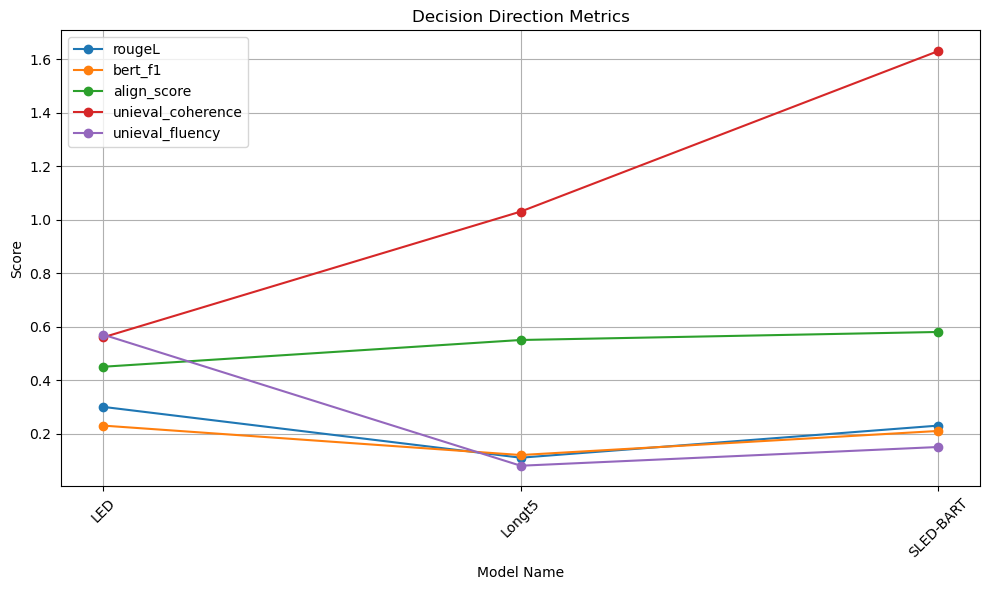

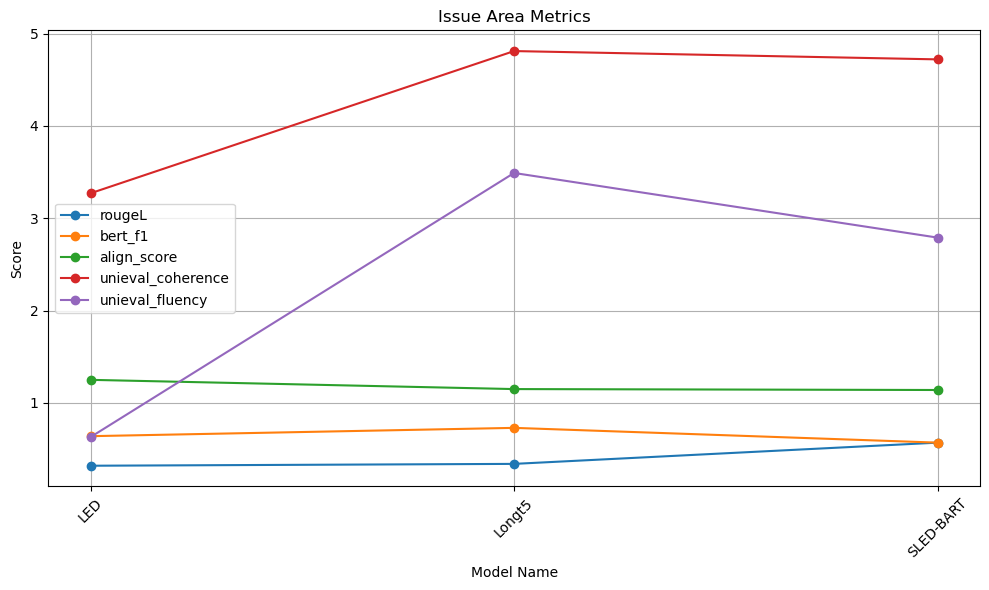

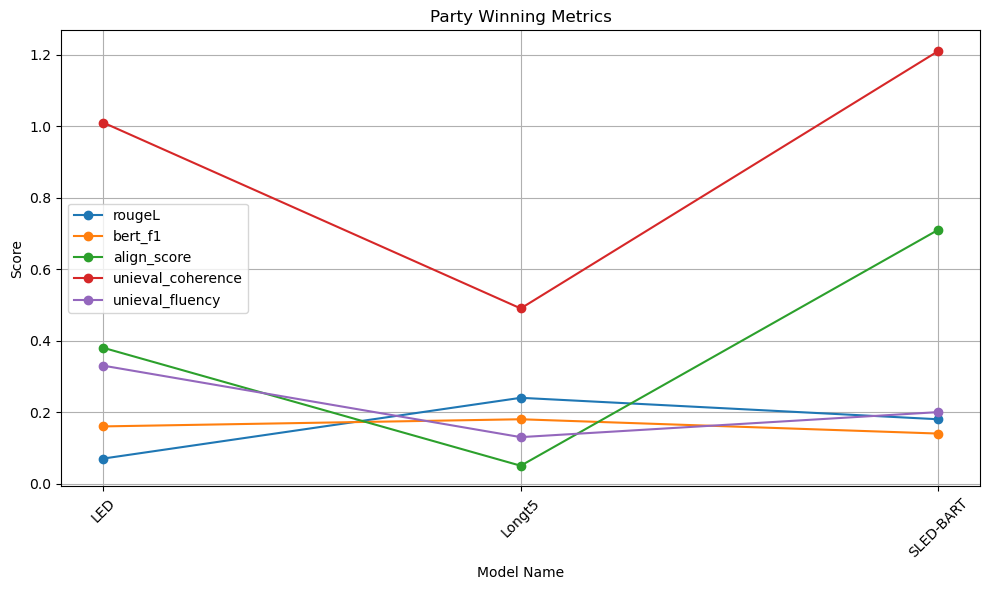

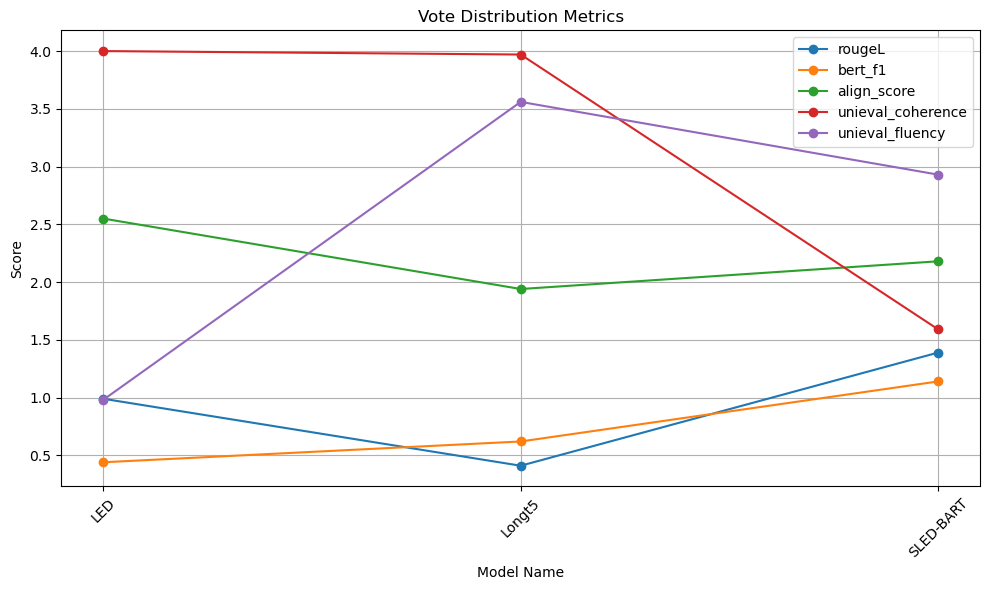

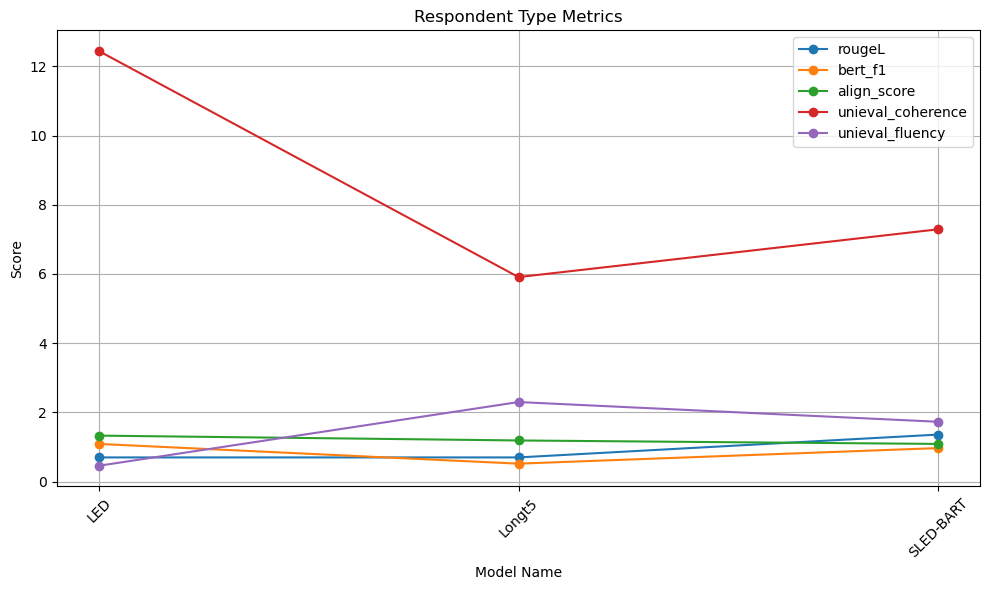

In [61]:
import matplotlib.pyplot as plt

def plot_metrics(df, title):
    plt.figure(figsize=(10, 6))
    x = df['Model-Name']
    for column in df.columns[1:]:
        plt.plot(x, df[column], marker='o', label=column)
    plt.title(title)
    plt.xlabel('Model Name')
    plt.ylabel('Score')
    plt.legend()
    plt.grid(True)
    plt.xticks(rotation=45)
    plt.tight_layout()
    plt.show()
# Plot each section
plot_metrics(decision_direction_df, 'Decision Direction Metrics')
plot_metrics(issue_area_df, 'Issue Area Metrics')
plot_metrics(party_winning_df, 'Party Winning Metrics')
plot_metrics(vote_distribution_df, 'Vote Distribution Metrics')
plot_metrics(respondent_type_df, 'Respondent Type Metrics')


In [54]:
# scores

import pandas as pd

# Data for different models and decision directions
data = {
    'Model Name': ['SLED', 'SLED', 'LongT5_BASE', 'LongT5_BASE', 'LED', 'LED'],
    'decisionDirection': [1.0, 2.0, 1.0, 2.0, 1.0, 2.0],
    # 'rouge1': [0.2881911282737702, 0.2800301687957089, 0.5006972341590501, 0.4984799876888322, 0.5617683378799088, 0.5562924589332737],
    # 'rouge2': [0.1317171105426093, 0.1281068932376469, 0.2131735639009587, 0.2134643223869962, 0.2778797516330901, 0.2771445012457565],
    'rougeL': [0.1493033586020747, 0.1446525430202634, 0.1938349974959564, 0.1959226530007171, 0.2540106064394946, 0.2479235056825909],
    'bert_f1': [0.6152169547463191, 0.6110136446199919, 0.6053124632089193, 0.6029296599982078, 0.6518436097006761, 0.6472673798862256],
    'align_score': [0.6051161299452527, 0.5934924882754945, 0.654448673925327, 0.6434980206322252, 0.5190971979430614, 0.5100159956174984],
    'unieval_coherence': [0.3252915840629001, 0.2927413773723101, 0.2257093625736734, 0.2463200756415417, 0.693876381579313, 0.7051346417482155],
    # 'unieval_consistency': [0.5806459555834281, 0.5738370837954399, 0.5581703818463227, 0.5535271798551213, 0.6208037524838069, 0.6173676354625844],
    'unieval_fluency': [0.5957881925856291, 0.5927041512412905, 0.69942365397513, 0.6978489674584478, 0.7348970198236824, 0.7234539347429343],
    # 'unieval_relevance': [0.3561893651550511, 0.3283792957778559, 0.2418436025612744, 0.2609725255071786, 0.6721295957472456, 0.6753723601362166],
    # 'unieval_overall': [0.4644787743467521, 0.4469154770467241, 0.4312867502391001, 0.4396671871155724, 0.680426687408512, 0.6803321430224877]
}

# Create DataFrame
df = pd.DataFrame(data)


In [56]:
df.iloc[:, 2:] = df.iloc[:, 2:] * 100


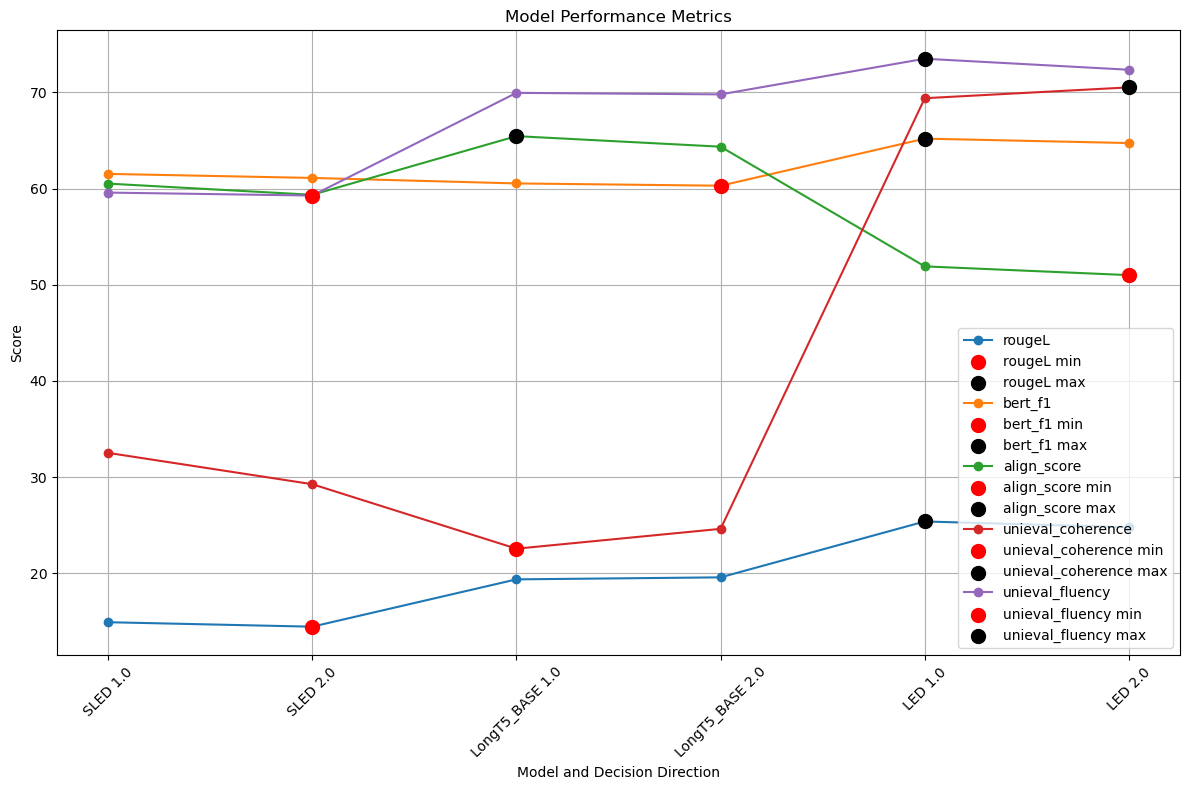

In [58]:
import matplotlib.pyplot as plt

def plot_metrics(df, title):
    plt.figure(figsize=(12, 8))
    x = df['Model Name'] + ' ' + df['decisionDirection'].astype(str)
    
    for column in df.columns[2:]:  # Skip 'Model Name' and 'decisionDirection'
        y = df[column]
        plt.plot(x, y, marker='o', label=column)
        
        # Highlight the minimum value
        min_index = y.idxmin()
        plt.scatter(x[min_index], y[min_index], color='red', s=100, zorder=5, label=f'{column} min')

        max_index = y.idxmax()        
        plt.scatter(x[max_index], y[max_index], color='black', s=100, zorder=5, label=f'{column} max')
    
    plt.title(title)
    plt.xlabel('Model and Decision Direction')
    plt.ylabel('Score')
    plt.legend()
    plt.grid(True)
    plt.xticks(rotation=45)
    plt.tight_layout()
    plt.show()

# Plot the metrics
plot_metrics(df, 'Model Performance Metrics')


/tmp/ipykernel_945446/3505474990.py:51: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(x, rotation=45)
/tmp/ipykernel_945446/3505474990.py:51: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(x, rotation=45)
/tmp/ipykernel_945446/3505474990.py:51: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(x, rotation=45)
/tmp/ipykernel_945446/3505474990.py:51: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(x, rotation=45)
/tmp/ipykernel_945446/3505474990.py:51: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xti

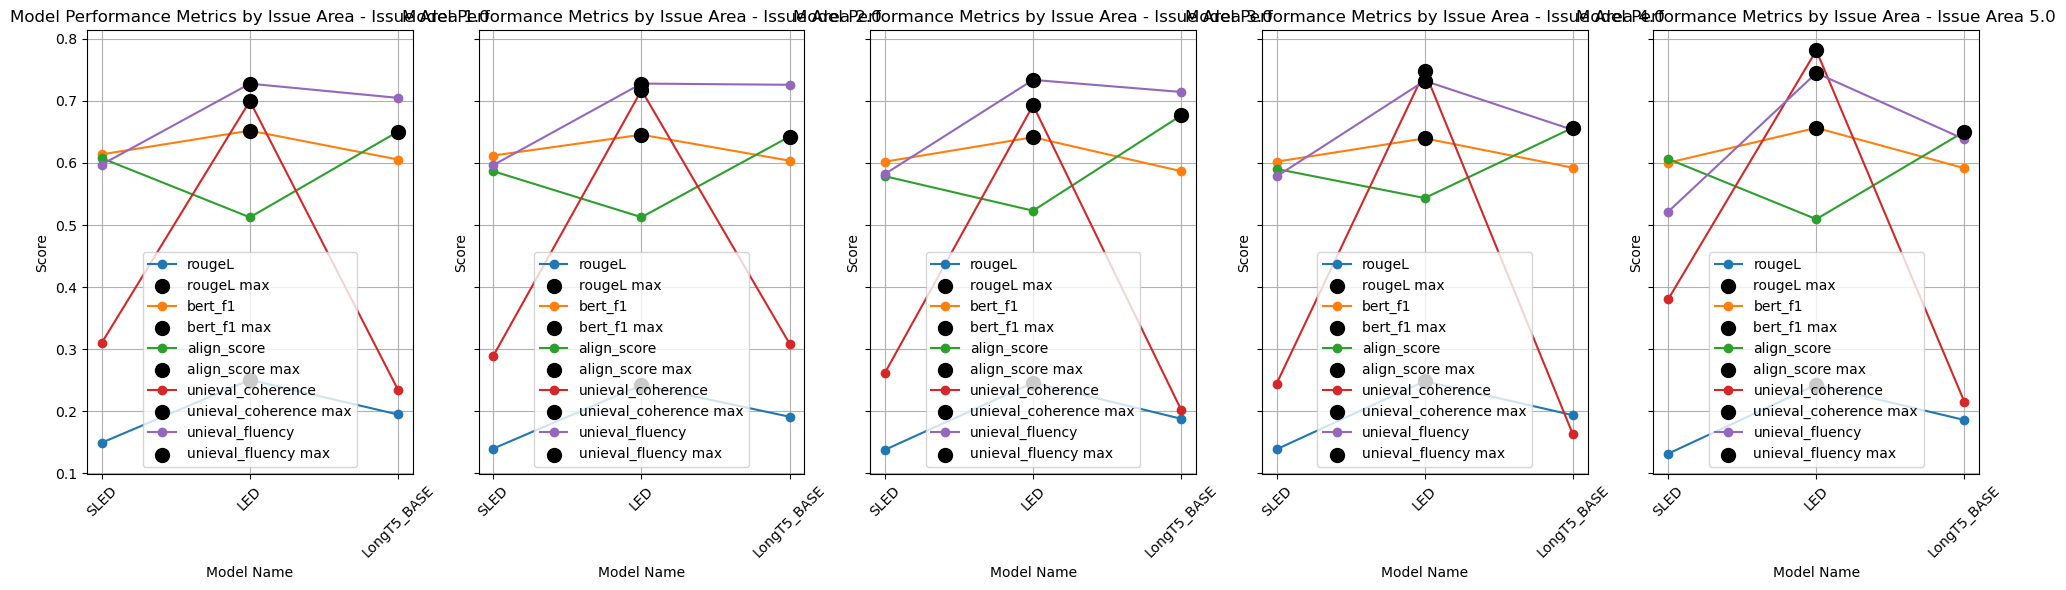

In [2]:
import pandas as pd
import matplotlib.pyplot as plt


# Data for different models and issue areas
data = {
    'Model Name': ['SLED', 'SLED', 'SLED', 'SLED', 'SLED', 'LED', 'LED', 'LED', 'LED', 'LED', 'LongT5_BASE', 'LongT5_BASE', 'LongT5_BASE', 'LongT5_BASE', 'LongT5_BASE'],
    'issueArea': [1.0, 2.0, 3.0, 4.0, 5.0, 1.0, 2.0, 3.0, 4.0, 5.0, 1.0, 2.0, 3.0, 4.0, 5.0],
    # 'rouge1': [0.2962739603319506, 0.2718900236459706, 0.266497915066227, 0.2729891638012175, 0.2552884056772083, 0.5754307949103452, 0.5431006848034883, 0.5241197077407356, 0.5539935289874548, 0.5347810630000664, 0.5019003808698291, 0.493732318221485, 0.4788176074156348, 0.4862585667697997, 0.4824139909930932],
    # 'rouge2': [0.1334450940264034, 0.1236226880009349, 0.1200999250182689, 0.1176469780199693, 0.1140124026208985, 0.2784342671117579, 0.2718092143012764, 0.2676639479722704, 0.2703124628135088, 0.2681784605461584, 0.2113644534346518, 0.2116733838784923, 0.2065272661860376, 0.2061605130914806, 0.2033490891796047],
    'rougeL': [0.1493812519847881, 0.1399270544575391, 0.1379349362603932, 0.1386865825365664, 0.1316595011073645, 0.250577111416924, 0.2421717224742623, 0.246029436018418, 0.2483992849407209, 0.2426686549812098, 0.1947863622588092, 0.1911124623568643, 0.187833993064512, 0.1936954017784374, 0.1858735385310468],
    'bert_f1': [0.6138290506142836, 0.6119751890500387, 0.6020661612351735, 0.6020506829023361, 0.6003312289714813, 0.6520466511066143, 0.6454866800043318, 0.6414421637852986, 0.639639464020729, 0.6565259456634521, 0.6055166751146317, 0.6036611537138621, 0.5867225468158722, 0.5923636347055435, 0.5915693998336792],
    'align_score': [0.6076580478594853, 0.5866418500741323, 0.5785995751619339, 0.5903035506606102, 0.6064331978559494, 0.5124378733910047, 0.5126140488518609, 0.5230748991171519, 0.5434320598840714, 0.50944584608078, 0.650456789135933, 0.6424860931105084, 0.6766059190034867, 0.6567103907465934, 0.6505045413970947],
    'unieval_coherence': [0.3102446569258303, 0.2894008204762921, 0.2619565962998461, 0.2444065941389725, 0.3803080611254796, 0.6996796498775885, 0.7172514825928188, 0.6929120872242883, 0.7474566228041708, 0.7811551494876214, 0.2346493894412919, 0.3087628239376286, 0.2020712558504532, 0.1631166789980237, 0.2151060443072196],
    # 'unieval_consistency': [0.5696098654724844, 0.5672891822209246, 0.525537710299875, 0.5681727086204361, 0.5871030784049965, 0.620635455074422, 0.6118250964201141, 0.5853899489356508, 0.63870751427503, 0.5995294477767098, 0.5560998860428334, 0.5734732218851094, 0.525693556101952, 0.5114508169499475, 0.4803515996068102],
    'unieval_fluency': [0.5974286889950786, 0.5966438018092035, 0.5822400125861215, 0.5782857618167745, 0.5214166886210387, 0.727691992135589, 0.727864072134103, 0.7338042128263353, 0.7322684379433826, 0.7449030518582049, 0.7048413378650373, 0.7259082515566091, 0.7143418334959365, 0.6533204993180868, 0.6381533197525153],
    # 'unieval_relevance': [0.34962637292755, 0.2874802548705613, 0.2589707661853153, 0.2520612348164422, 0.451053140752283, 0.6760080128145739, 0.6933280989332812, 0.6447229789285138, 0.7193211515532136, 0.7373881675235825, 0.2461874321440249, 0.3371694176757532, 0.2270933510359198, 0.1713906307383182, 0.2151218000384046],
    # 'unieval_overall': [0.4567273960802359, 0.4352035148442453, 0.4071762713427894, 0.4107315748481563, 0.4849702422259495, 0.6810037774755433, 0.6875671875200793, 0.6642073069786971, 0.7094384316439493, 0.7157439541615297, 0.4354445113732968, 0.4863284287637751, 0.4172999991210654, 0.374819656501094, 0.3871831909262375]
}

# Create DataFrame
df = pd.DataFrame(data)


def plot_metrics(df, title):
    unique_issue_areas = df['issueArea'].unique()
    fig, axes = plt.subplots(nrows=1, ncols=len(unique_issue_areas), figsize=(20, 6), sharey=True)
    
    for i, issue_area in enumerate(unique_issue_areas):
        ax = axes[i]
        df_filtered = df[df['issueArea'] == issue_area]
        x = df_filtered['Model Name']
        
        for column in df_filtered.columns[2:]:  # Skip 'Model Name' and 'issueArea'
            y = df_filtered[column]
            ax.plot(x, y, marker='o', label=column)
            
            # Highlight the minimum value
            min_index = y.idxmin()
            # ax.scatter(x[min_index], y[min_index], color='red', s=100, zorder=5, label=f'{column} min')
            
            max_index = y.idxmax()        
            ax.scatter(x[max_index], y[max_index], color='black', s=100, zorder=5, label=f'{column} max')
    
        
        ax.set_title(f"{title} - Issue Area {issue_area}")
        ax.set_xlabel('Model Name')
        ax.set_ylabel('Score')
        ax.legend()
        ax.grid(True)
        ax.set_xticklabels(x, rotation=45)
    
    plt.tight_layout()
    plt.show()

# Plot the metrics
plot_metrics(df, 'Model Performance Metrics by Issue Area')



# RQ2

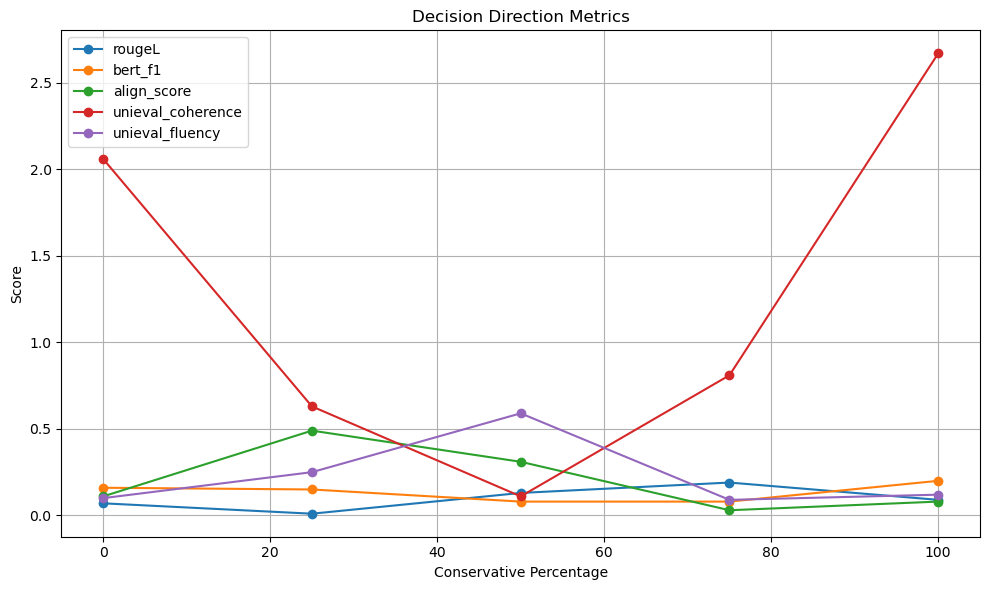

In [43]:
import pandas as pd
import matplotlib.pyplot as plt
# Data for Decision Direction
decision_direction_data = {
    'Conservative%': [0, 25, 50, 75, 100],
    'Liberal%': [100, 75, 50, 25, 0],
    # 'rouge1': [0.46, 0.39, 0.16, 0.23, 0.24],
    # 'rouge2': [0.19, 0.08, 0.11, 0.10, 0.05],
    'rougeL': [0.07, 0.01, 0.13, 0.19, 0.09],
    'bert_f1': [0.16, 0.15, 0.08, 0.08, 0.20],
    'align_score': [0.11, 0.49, 0.31, 0.03, 0.08],
    'unieval_coherence': [2.06, 0.63, 0.11, 0.81, 2.67],
    # 'unieval_consistency': [0.66, 0.61, 0.54, 0.27, 0.25],
    'unieval_fluency': [0.10, 0.25, 0.59, 0.09, 0.12]
}
# Create DataFrame
decision_direction_df = pd.DataFrame(decision_direction_data)
def plot_metrics(df, title):
    plt.figure(figsize=(10, 6))
    x = df['Conservative%']
    for column in df.columns[2:]:  # Skip 'Conservative%' and 'Liberal%'
        plt.plot(x, df[column], marker='o', label=column)
    plt.title(title)
    plt.xlabel('Conservative Percentage')
    plt.ylabel('Score')
    plt.legend()
    plt.grid(True)
    plt.tight_layout()
    plt.show()
# Plot the Decision Direction metrics
plot_metrics(decision_direction_df, 'Decision Direction Metrics')

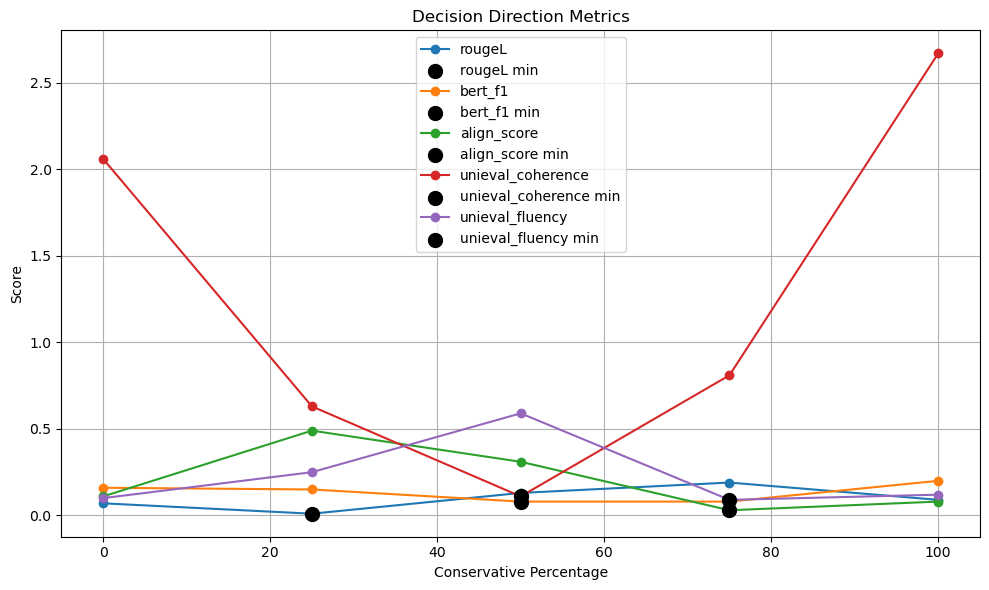

In [44]:
import matplotlib.pyplot as plt

def plot_metrics(df, title):
    plt.figure(figsize=(10, 6))
    x = df['Conservative%']
    
    for column in df.columns[2:]:  # Skip 'Conservative%' and 'Liberal%'
        y = df[column]
        plt.plot(x, y, marker='o', label=column)
        
        # Highlight the minimum value
        min_index = y.idxmin()
        plt.scatter(x[min_index], y[min_index], color='black', s=100, zorder=5, label=f'{column} min')
    
    plt.title(title)
    plt.xlabel('Conservative Percentage')
    plt.ylabel('Score')
    plt.legend()
    plt.grid(True)
    plt.tight_layout()
    plt.show()

# Plot the Decision Direction metrics
plot_metrics(decision_direction_df, 'Decision Direction Metrics')


In [45]:
import pandas as pd

# Data for Decision Direction
original_results_data = {
    'data-percentage': [
        'conservative', 'liberal', 'mixed', 'mixed_liberal_75', 'mixed_conservative_75',
        'liberal', 'mixed_conservative_75', 'mixed', 'conservative', 'mixed_liberal_75'
    ],
    'decisionDirection': [1, 1, 1, 1, 1, 2, 2, 2, 2, 2],
    # 'rouge1': [0.54, 0.56, 0.57, 0.57, 0.57, 0.57, 0.56, 0.57, 0.54, 0.56],
    # 'rouge2': [0.26, 0.27, 0.28, 0.28, 0.28, 0.28, 0.27, 0.28, 0.26, 0.27],
    'rougeL': [0.24, 0.24, 0.24, 0.24, 0.24, 0.24, 0.24, 0.24, 0.23, 0.24],
    'bert_f1': [0.65, 0.64, 0.65, 0.64, 0.64, 0.64, 0.64, 0.64, 0.64, 0.64],
    'align_score': [0.68, 0.68, 0.69, 0.69, 0.69, 0.68, 0.69, 0.69, 0.69, 0.68],
    'unieval_coherence': [0.65, 0.66, 0.73, 0.68, 0.74, 0.70, 0.73, 0.73, 0.70, 0.70],
    # 'unieval_consistency': [0.61, 0.60, 0.61, 0.63, 0.61, 0.59, 0.61, 0.60, 0.61, 0.61],
    'unieval_fluency': [0.72, 0.71, 0.72, 0.71, 0.72, 0.71, 0.71, 0.71, 0.73, 0.70],
    # 'unieval_relevance': [0.61, 0.64, 0.71, 0.67, 0.73, 0.69, 0.71, 0.72, 0.67, 0.68],
    # 'unieval_overall': [0.65, 0.65, 0.69, 0.67, 0.70, 0.67, 0.69, 0.69, 0.68, 0.67]
}

# Create DataFrame
original_results_df = pd.DataFrame(original_results_data)


In [46]:
# Define the desired order
order = ['liberal', 'mixed_liberal_75', 'mixed', 'mixed_conservative_75', 'conservative']

# Convert 'data-percentage' to a categorical type with the specified order
original_results_df['data-percentage'] = pd.Categorical(
    original_results_df['data-percentage'],
    categories=order,
    ordered=True
)

# Sort the DataFrame based on the new categorical order
original_results_df.sort_values(by=['decisionDirection', 'data-percentage'], inplace=True)


In [47]:
# Multiply all columns except 'decisionDirection' by 100
original_results_df.iloc[:, 2:] = original_results_df.iloc[:, 2:] * 100


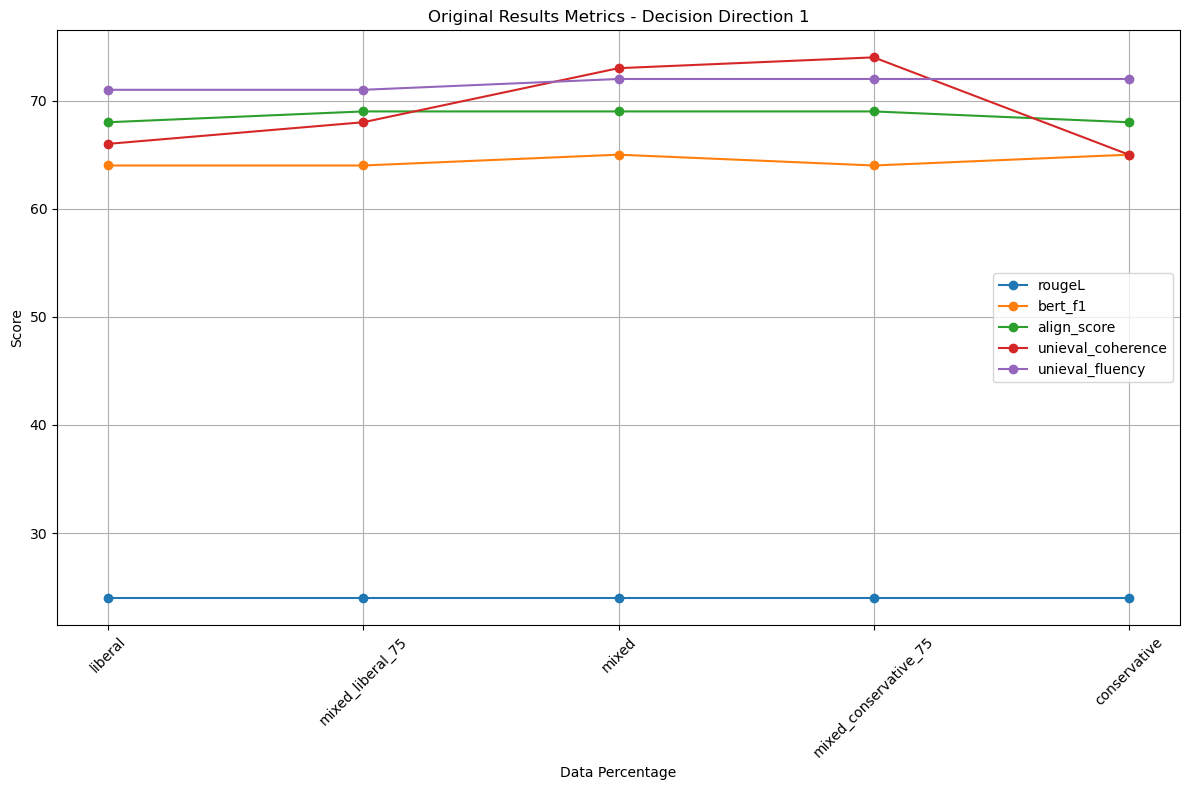

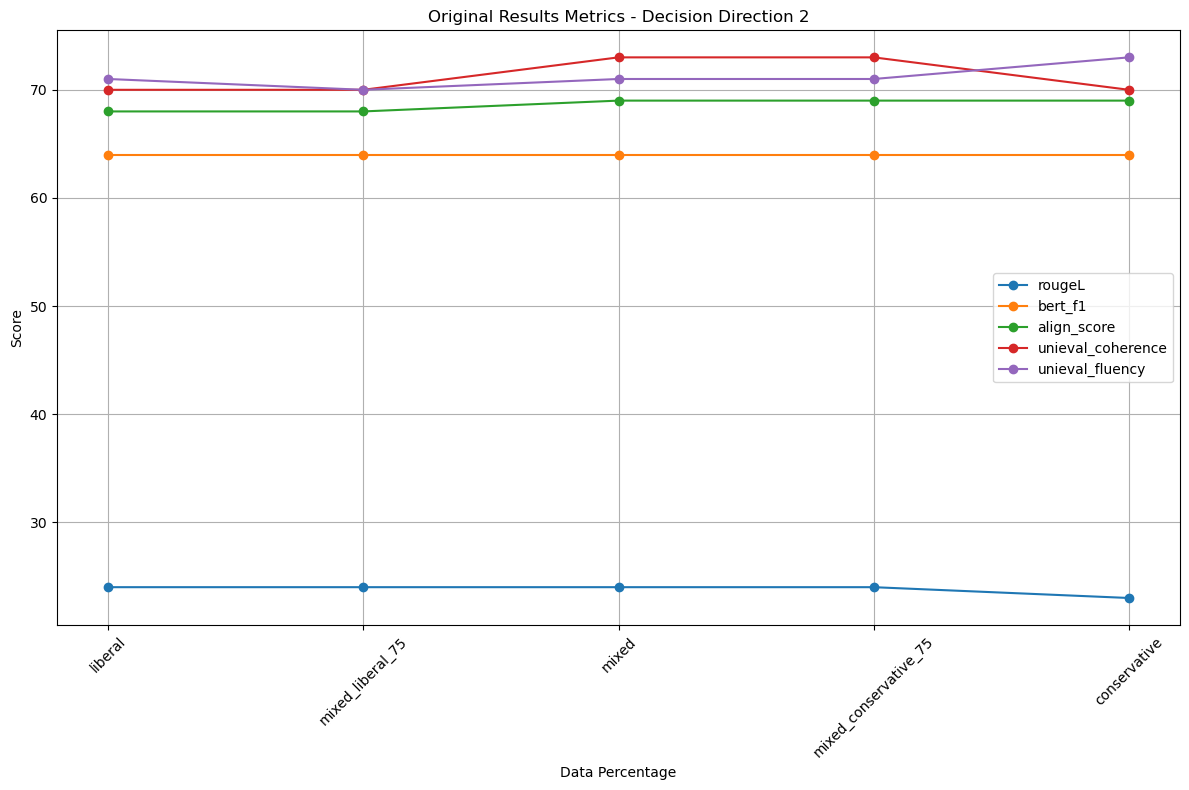

In [48]:
import matplotlib.pyplot as plt

def plot_metrics(df, title, decision_direction):
    plt.figure(figsize=(12, 8))
    # Filter data for the specific decision direction
    df_filtered = df[df['decisionDirection'] == decision_direction]
    x = df_filtered['data-percentage']
    for column in df_filtered.columns[2:]:  # Skip 'data-percentage' and 'decisionDirection'
        plt.plot(x, df_filtered[column], marker='o', label=column)
    plt.title(f"{title} - Decision Direction {decision_direction}")
    plt.xlabel('Data Percentage')
    plt.ylabel('Score')
    plt.legend()
    plt.grid(True)
    plt.xticks(rotation=45)
    plt.tight_layout()
    plt.show()

# Plot the original results for each decision direction
plot_metrics(original_results_df, 'Original Results Metrics', decision_direction=1)
plot_metrics(original_results_df, 'Original Results Metrics', decision_direction=2)


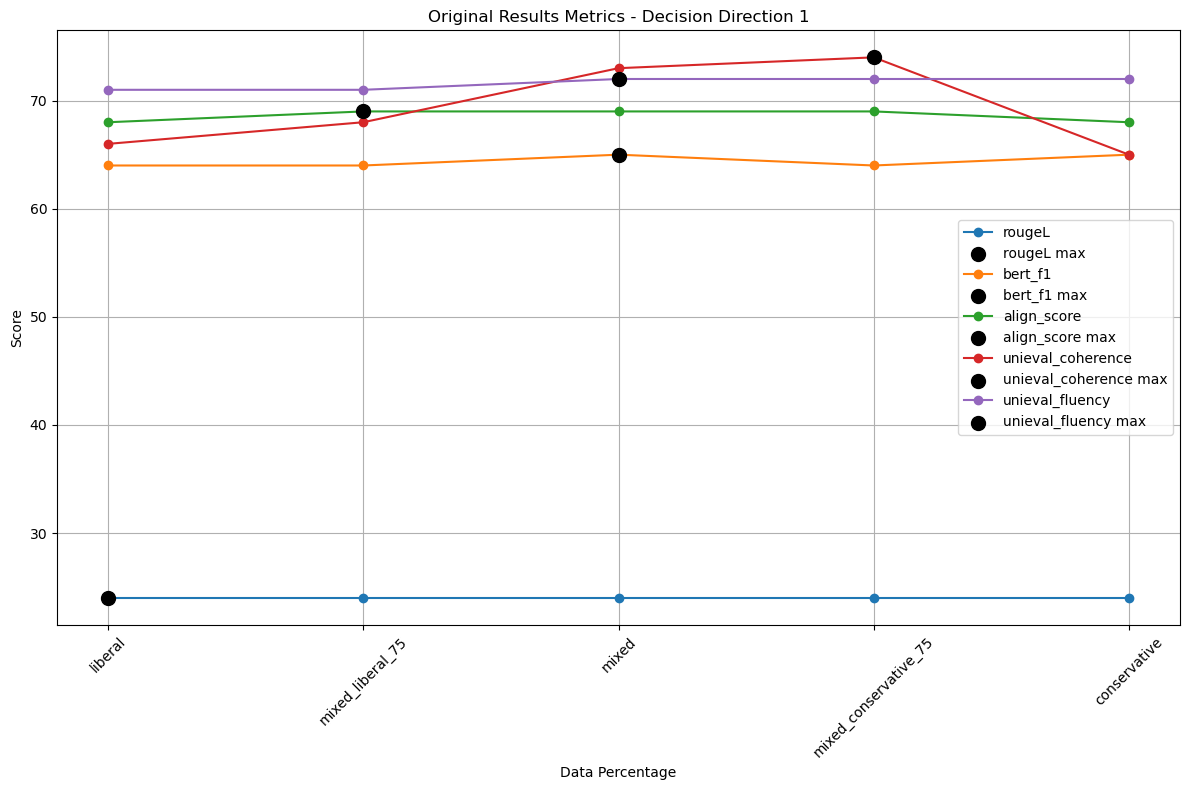

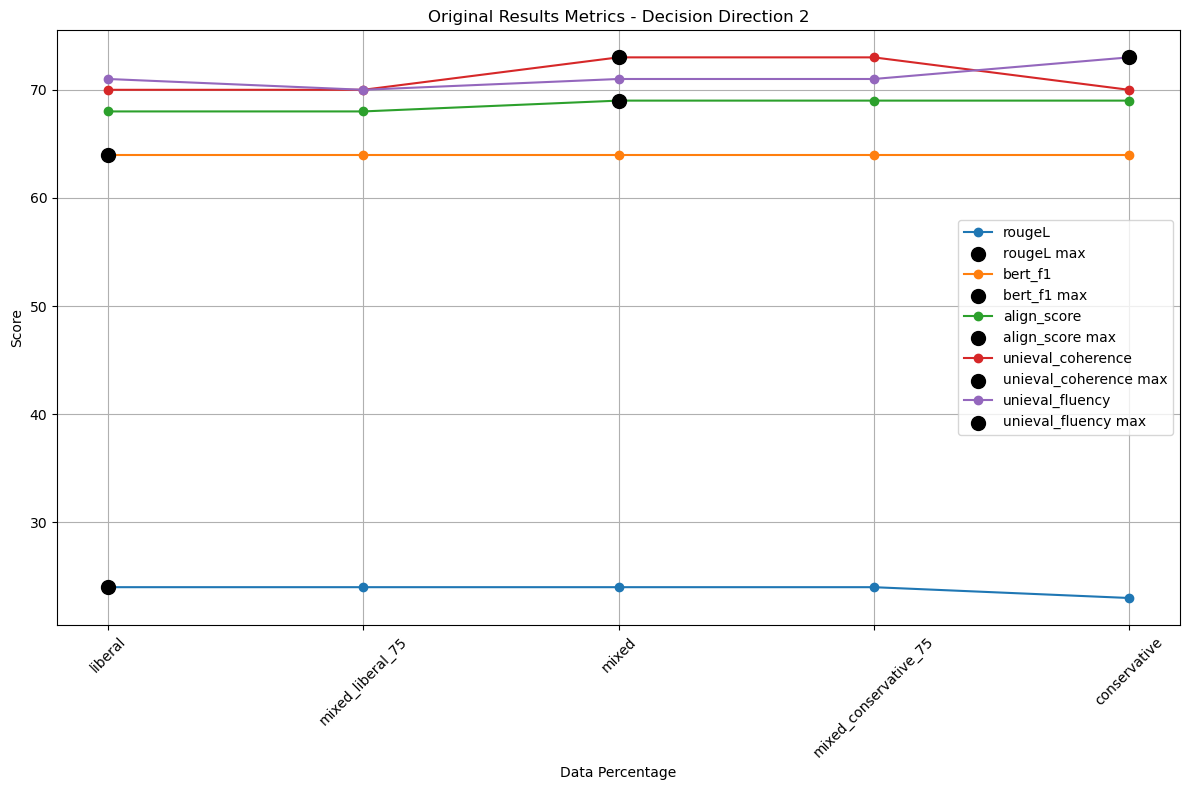

In [49]:
import matplotlib.pyplot as plt

def plot_metrics(df, title, decision_direction):
    plt.figure(figsize=(12, 8))
    # Filter data for the specific decision direction
    df_filtered = df[df['decisionDirection'] == decision_direction]
    x = df_filtered['data-percentage']
    
    for column in df_filtered.columns[2:]:  # Skip 'data-percentage' and 'decisionDirection'
        y = df_filtered[column]
        plt.plot(x, y, marker='o', label=column)
        
        # Highlight the highest and lowest values
        max_index = y.idxmax()
        min_index = y.idxmin()
        
        plt.scatter(x[max_index], y[max_index], color='black', s=100, zorder=5, label=f'{column} max')
        # plt.scatter(x[min_index], y[min_index], color='red', s=100, zorder=5, label=f'{column} min')
    
    plt.title(f"{title} - Decision Direction {decision_direction}")
    plt.xlabel('Data Percentage')
    plt.ylabel('Score')
    plt.legend()
    plt.grid(True)
    plt.xticks(rotation=45)
    plt.tight_layout()
    plt.show()

# Plot the original results for each decision direction
plot_metrics(original_results_df, 'Original Results Metrics', decision_direction=1)
plot_metrics(original_results_df, 'Original Results Metrics', decision_direction=2)
